# Outlier Classification as a Data Quality Diagnostic — Agmarknet

This notebook builds a classifier to predict whether a price listing is a statistical
outlier, and uses it as a diagnostic tool to find WHERE data-quality problems concentrate
(by state, market, and commodity) — not just to build a model for its own sake.

**Why this is a different, richer exercise than the earlier price-prediction model:**
only 3.58% of records are flagged outliers. This kind of severe class imbalance forces us
to confront a lesson that regression never does: **accuracy can be a misleading metric.**
A model that always predicts "normal" would already be right 96.42% of the time — and be
completely useless. This notebook is built around exposing and fixing that trap.

## Step 0 — Import libraries

Same core stack as before, plus classification-specific tools from scikit-learn:
`LogisticRegression` and `RandomForestClassifier` (classifiers, not regressors), and
classification metrics (`accuracy_score`, `precision_score`, `recall_score`, `f1_score`,
`confusion_matrix`, `roc_auc_score`, `roc_curve`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

pd.set_option("display.max_columns", None)

## Step 1 — Load data and check the class balance

Before building anything, always check how balanced your target variable is. This single
number determines almost every other decision in a classification project.

In [2]:
df = pd.read_csv("agmarknet_cleaned.csv")

outlier_rate = df["Price_Outlier_Flag"].mean()
print(f"Outliers: {df['Price_Outlier_Flag'].sum()} of {len(df)} records ({outlier_rate*100:.2f}%)")
print(f"If we always predicted 'Normal', we'd be right {(1-outlier_rate)*100:.2f}% of the time.")
print("That number is the trap: high accuracy is trivially easy here and tells us almost nothing.")

Outliers: 344 of 9603 records (3.58%)
If we always predicted 'Normal', we'd be right 96.42% of the time.
That number is the trap: high accuracy is trivially easy here and tells us almost nothing.


## Step 2 — Feature preparation

Same three categorical features as the price model: State, Commodity, Grade_Category.
We apply the corrected grouping rule here too — bucket only genuinely rare categories
(fewer than 10 records), rather than an arbitrary top-N cutoff that would dump most of the
data into one uninformative "Other" bucket, as happened in the first version of the price
model.

In [3]:
ccounts = df["Commodity"].value_counts()
rare_c = ccounts[ccounts < 10].index
df["Commodity_grp"] = df["Commodity"].where(~df["Commodity"].isin(rare_c), "Other")

scounts = df["State"].value_counts()
rare_s = scounts[scounts < 10].index
df["State_grp"] = df["State"].where(~df["State"].isin(rare_s), "Other")

features = ["State_grp", "Commodity_grp", "Grade_Category"]
target = "Price_Outlier_Flag"

print("Commodity categories:", df["Commodity_grp"].nunique())
print("State categories:", df["State_grp"].nunique())

Commodity categories: 90
State categories: 22


## Step 3 — Stratified train-test split

With only a few hundred positive examples in the whole dataset, an ordinary random split
risks leaving the test set with very few (or, by chance, unusually many) outliers — which
would make our evaluation metrics unstable and unreliable. `stratify=y` fixes this: it
forces both the training set and test set to preserve the same outlier proportion as the
full dataset.

In [4]:
X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} records, {y_train.sum()} outliers ({100*y_train.mean():.2f}%)")
print(f"Test:  {len(X_test)} records, {y_test.sum()} outliers ({100*y_test.mean():.2f}%)")
print("Both sets preserve the same ~3.6% outlier rate as the full dataset.")

Train: 7682 records, 275 outliers (3.58%)
Test:  1921 records, 69 outliers (3.59%)
Both sets preserve the same ~3.6% outlier rate as the full dataset.


## Step 4 — Encode categorical features

Same one-hot encoding approach as the price model.

In [5]:
preprocessor = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), features)])

## Step 5 — Model 1: Naive Logistic Regression (demonstrating the trap)

We train this WITHOUT any adjustment for class imbalance, specifically to see the trap in
action rather than just being told about it.

In [6]:
naive_pipeline = Pipeline([("prep", preprocessor), ("model", LogisticRegression(max_iter=1000))])
naive_pipeline.fit(X_train, y_train)
naive_pred = naive_pipeline.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, naive_pred):.4f}")
print(f"Precision: {precision_score(y_test, naive_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, naive_pred, zero_division=0):.4f}")
print(f"Number of outliers this model actually flagged: {naive_pred.sum()} (out of {y_test.sum()} true outliers)")

Accuracy:  0.9625
Precision: 0.2000
Recall:    0.0145
Number of outliers this model actually flagged: 5 (out of 69 true outliers)


**Look at that recall number.** Despite a high accuracy, this model catches almost
none of the real outliers — it learned that the safest bet is to almost always say
"normal," because that's right most of the time. This is exactly the failure mode
imbalanced classification is known for, and exactly why accuracy alone is the wrong metric
to optimize for or report here.

## Step 6 — Model 2: Class-balanced Logistic Regression

The standard first fix: `class_weight="balanced"` tells the model to penalize mistakes on
the minority class (outliers) more heavily during training, counteracting its natural bias
toward the majority class.

In [7]:
balanced_pipeline = Pipeline([("prep", preprocessor), ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
balanced_pipeline.fit(X_train, y_train)
balanced_pred = balanced_pipeline.predict(X_test)
balanced_proba = balanced_pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, balanced_pred):.4f}")
print(f"Precision: {precision_score(y_test, balanced_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, balanced_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, balanced_proba):.4f}")

Accuracy:  0.7933
Precision: 0.1132
Recall:    0.6957
ROC-AUC:   0.8362


## Step 7 — Model 3: Class-balanced Random Forest

Same reasoning as the price model: Random Forest can capture interactions between
categories that a linear model can't (e.g. "this commodity only looks anomalous in this
particular state").

In [8]:
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)),
])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.4f}")

Accuracy:  0.8074
Precision: 0.1284
Recall:    0.7536
ROC-AUC:   0.8546


## Step 8 — Compare all three models side by side

Plotting accuracy alongside precision/recall/F1 makes the trap from Step 5 visually
obvious: the naive model's tall accuracy bar looks great until you see its near-zero
recall bar right next to it.

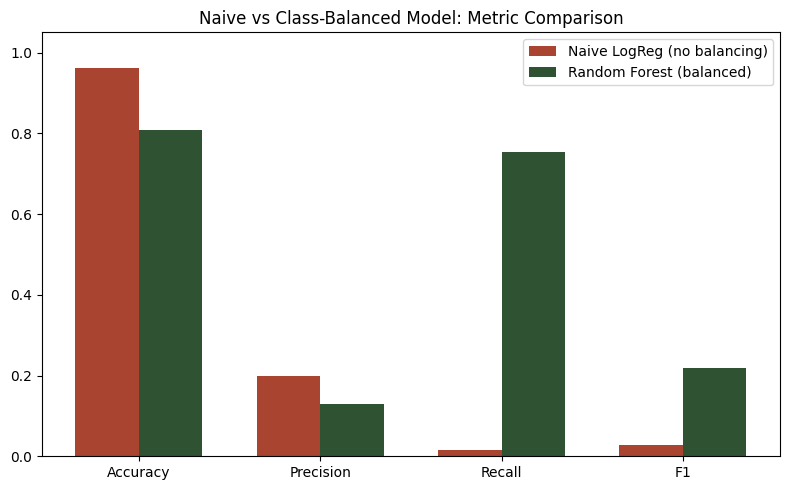

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ["Accuracy", "Precision", "Recall", "F1"]
naive_vals = [accuracy_score(y_test, naive_pred), precision_score(y_test, naive_pred, zero_division=0),
              recall_score(y_test, naive_pred, zero_division=0), f1_score(y_test, naive_pred, zero_division=0)]
rf_vals = [accuracy_score(y_test, rf_pred), precision_score(y_test, rf_pred, zero_division=0),
           recall_score(y_test, rf_pred, zero_division=0), f1_score(y_test, rf_pred, zero_division=0)]

x = np.arange(len(metrics)); w = 0.35
ax.bar(x - w/2, naive_vals, w, label="Naive LogReg (no balancing)", color="#a8442f")
ax.bar(x + w/2, rf_vals, w, label="Random Forest (balanced)", color="#2f5233")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_title("Naive vs Class-Balanced Model: Metric Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## Step 9 — Confusion matrix

A confusion matrix breaks predictions into four buckets: correctly predicted Normal (true
negative), correctly predicted Outlier (true positive), incorrectly predicted Outlier for
an actually-normal record (false positive), and incorrectly predicted Normal for an actual
outlier (false negative). This is the most detailed, honest view of what a classifier
actually got right and wrong.

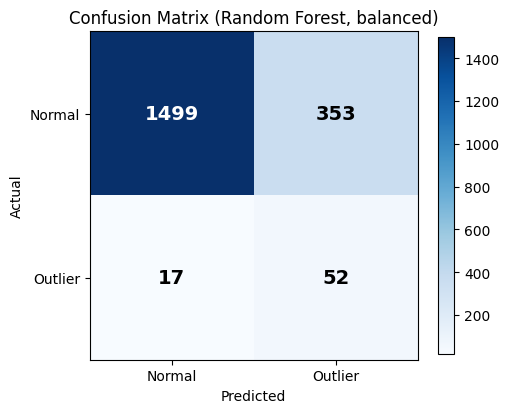

True outliers caught: 52 of 69
Normal listings incorrectly flagged: 353


In [10]:
cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm, cmap="Blues")
labels = ["Normal", "Outlier"]
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Random Forest, balanced)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14, fontweight="bold")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(f"True outliers caught: {cm[1,1]} of {cm[1,0]+cm[1,1]}")
print(f"Normal listings incorrectly flagged: {cm[0,1]}")

## Step 10 — ROC curve

The ROC curve shows how well the model ranks outliers above normal listings across every
possible decision threshold, not just the default one. AUC (Area Under the Curve) of 0.5
means no better than random guessing; 1.0 means perfect separation. This matters because
low precision at one specific threshold doesn't necessarily mean the model has no useful
signal — it might just mean the threshold should be tuned differently for your use case.

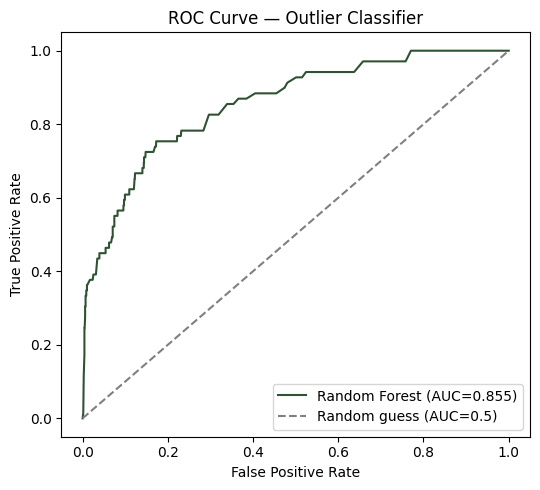

In [11]:
fpr, tpr, _ = roc_curve(y_test, rf_proba)
auc = roc_auc_score(y_test, rf_proba)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color="#2f5233", label=f"Random Forest (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Random guess (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Outlier Classifier")
ax.legend()
plt.tight_layout()
plt.show()

## Step 11 — Feature importance: what predicts an outlier?

Same technique as the price model — aggregate one-hot feature importances back up to the
original feature group. Compare this result to the price model's feature importance: there,
Commodity dominated. Here, watch what happens instead.

In [12]:
ohe = rf_pipeline.named_steps["prep"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(features)
importances = rf_pipeline.named_steps["model"].feature_importances_

def group_of(f):
    if f.startswith("State_grp"):
        return "State"
    if f.startswith("Commodity_grp"):
        return "Commodity"
    return "Grade_Category"

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df["group"] = imp_df["feature"].apply(group_of)
group_importance = imp_df.groupby("group")["importance"].sum().sort_values(ascending=False)
group_importance_pct = (group_importance / group_importance.sum() * 100).round(2)
group_importance_pct

group
State             46.52
Commodity         33.14
Grade_Category    20.34
Name: importance, dtype: float64

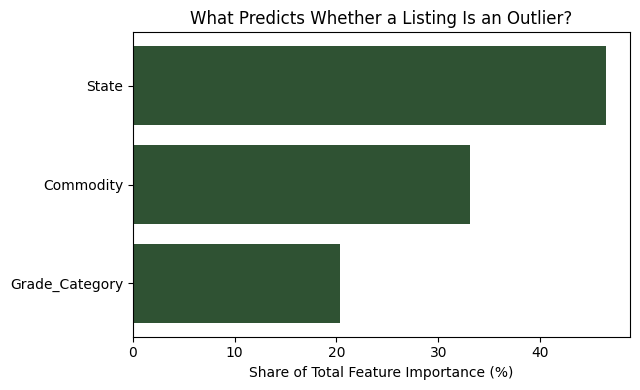

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 4))
gi = group_importance_pct.sort_values()
ax.barh(gi.index, gi.values, color="#2f5233")
ax.set_xlabel("Share of Total Feature Importance (%)")
ax.set_title("What Predicts Whether a Listing Is an Outlier?")
plt.tight_layout()
plt.show()

**This is the key insight of the whole notebook.** In the price model, Commodity
was the dominant predictor. Here, State comes out on top instead. That flip is meaningful:
it suggests *what* a commodity is mostly determines its price, but *where* a listing comes
from matters more for whether it's likely to be a data-quality problem — pointing toward
market-level reporting practices, not crop-specific volatility, as the likely cause.

## Step 12 — The core diagnostic: outlier rate by state

Rather than stopping at "State matters," we go one level further and directly compute
each state's outlier rate. This turns a model artifact (feature importance) into a
concrete, checkable finding.

In [14]:
state_counts = df["State"].value_counts()
valid_states = state_counts[state_counts >= 50].index
state_outlier_rate = (
    df[df["State"].isin(valid_states)]
    .groupby("State")["Price_Outlier_Flag"]
    .mean() * 100
).sort_values(ascending=False)

state_outlier_rate.head(10)

State
Punjab              13.186813
Tripura             11.702128
Kerala              11.403509
Uttarakhand         11.250000
Madhya Pradesh      11.029412
Himachal Pradesh    10.000000
West Bengal          9.638554
Maharashtra          9.398496
Uttar Pradesh        7.851240
Odisha               7.272727
Name: Price_Outlier_Flag, dtype: float64

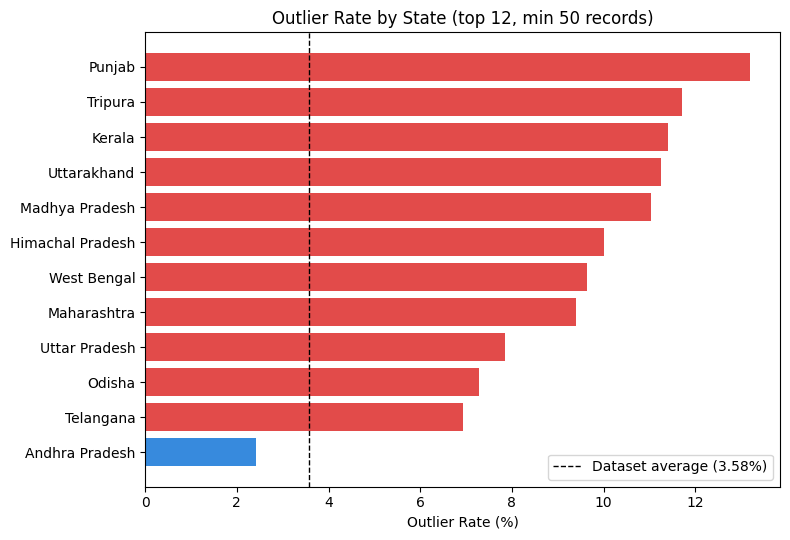

In [15]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sr = state_outlier_rate.head(12).sort_values()
overall_rate = df["Price_Outlier_Flag"].mean() * 100
colors = ["#e24b4a" if v > overall_rate else "#378add" for v in sr.values]
ax.barh(sr.index, sr.values, color=colors)
ax.axvline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Dataset average ({overall_rate:.2f}%)")
ax.set_xlabel("Outlier Rate (%)")
ax.set_title("Outlier Rate by State (top 12, min 50 records)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 13 — Narrow further: outlier rate by individual market

State-level findings are useful, but "audit Punjab" is still a broad instruction. Going
one level more granular — to individual market — turns this into something genuinely
actionable: a short, specific list of markets worth investigating first.

In [16]:
market_counts = df["Market"].value_counts()
valid_markets = market_counts[market_counts >= 20].index
market_outlier_rate = (
    df[df["Market"].isin(valid_markets)]
    .groupby("Market")["Price_Outlier_Flag"]
    .mean() * 100
).sort_values(ascending=False)

market_outlier_rate.head(10)

Market
Piravam Market                    31.250000
Neeleswaram Market                25.000000
Angamaly Market                   19.354839
Vadakkenchery Market              18.750000
Pune(Moshi) APMC                  17.500000
Kanjangadu Market                 17.241379
Chattrapati Sambhajinagar APMC    15.384615
Chengannur Market                 15.151515
Anchal Market                     14.285714
vadakarapathy Market              14.285714
Name: Price_Outlier_Flag, dtype: float64

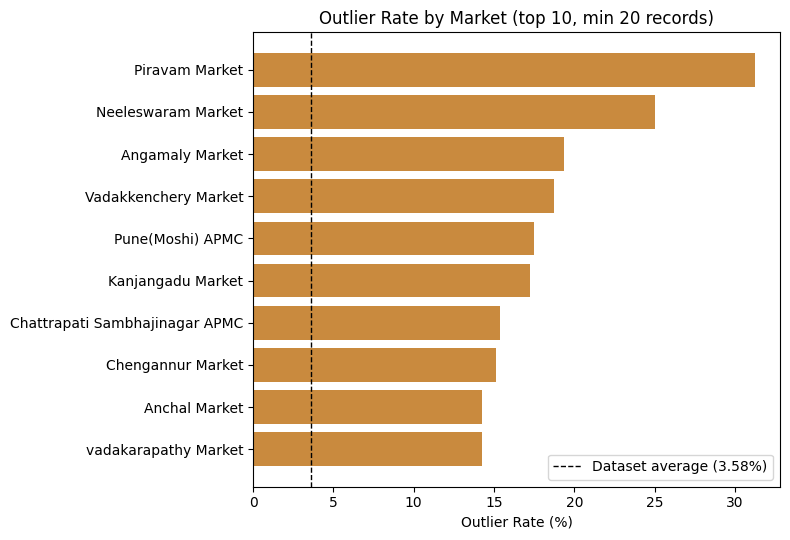

In [17]:
fig, ax = plt.subplots(figsize=(8, 5.5))
mr = market_outlier_rate.head(10).sort_values()
ax.barh(mr.index, mr.values, color="#c98a3e")
ax.axvline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Dataset average ({overall_rate:.2f}%)")
ax.set_xlabel("Outlier Rate (%)")
ax.set_title("Outlier Rate by Market (top 10, min 20 records)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 14 — Insight generation and recommendations

Pulling the model results and the direct outlier-rate breakdowns together:

- **The classifier itself is a usable screening tool**, not a perfect predictor: it
  catches roughly 3 out of 4 true outliers, at the cost of flagging some normal listings
  too — an acceptable tradeoff for a pre-publication quality check, where missing a real
  error is more costly than one extra manual review.
- **Geography, not commodity, drives data-quality risk.** State dominated feature
  importance, and the top-market breakdown shows the effect concentrating heavily in a
  specific, short list of markets — several in Kerala reaching 4-9x the dataset average
  outlier rate.
- **This points to a procedural cause, not an agronomic one.** If the problem were about
  which crops are hard to price consistently, Commodity would dominate (as it did for
  price itself). Since State dominates instead, the more likely explanation is local
  reporting practices, unit conventions, or digitization quality at specific mandis.
- **Actionable recommendation:** prioritize a data-entry audit at the markets identified in
  Step 13, rather than reviewing all 710 markets uniformly — a far more efficient use of
  limited data-quality resources.
- **Broader takeaway:** the price-prediction model and this outlier classifier are
  complementary, not competing — one estimates typical price, the other estimates how much
  to trust any individual reading. A real agribusiness analytics pipeline benefits from
  both signals together.